# Part I: Exploratory Data Analysis
## US Airlines On-Time Performance - 2025 Departure and Arrival Delay Analysis


## Introduction

This notebook explores the Bureau of Transportation Statistics **Reporting Carrier On-Time Performance Data** for 2025 (~7 million flights). The analysis focuses on understanding what drives flight delays, both at departure and arrival, and how delays accumulate or dissipate over the course of a flight.

**Three guiding questions:**
1. **Q1 (Departure):** What factors most significantly influence flight departure delays?
2. **Q2 (Arrival):** What factors most significantly influence flight arrival delays?
3. **Q3 (Comparison):** How do the factors affecting departure delays differ from those affecting arrival delays?

This framing traces how delays accumulate (or get resolved) over the course of a flight. Departure delays reflect conditions at the origin (weather, airline operations, air traffic). Arrival delays reflect conditions at the destination plus any delays that accumulated en route. Comparing the two reveals where delays are introduced versus where they are mitigated.


## Step 0: Setup and Data Loading


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from zipfile import ZipFile
import warnings

warnings.simplefilter('ignore')

sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


### Load dataset (selected columns only to manage memory)

The raw 2025 BTS monthly ZIP files are committed under `data/raw/` with Git LFS. This notebook loads the selected analysis columns directly from `data/raw/`, or from `data/processed/combined_2025.csv` if that optional local cache exists.


In [3]:
cols = ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'IATA_CODE_Reporting_Airline', 'Origin', 'OriginCityName', 'OriginState', 'Dest', 'DestCityName', 'DestState', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode', 'Diverted', 'ActualElapsedTime', 'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

DATA_DIR = Path('data/raw')
PROCESSED_DATA = Path('data/processed/combined_2025.csv')
ZIP_PATTERN = 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_*.zip'


def month_number(path):
    return int(path.stem.rsplit('_', 1)[-1])


def read_monthly_zip(zip_path, columns):
    with ZipFile(zip_path) as archive:
        csv_name = next(name for name in archive.namelist() if name.lower().endswith('.csv'))
        with archive.open(csv_name) as csv_file:
            return pd.read_csv(csv_file, usecols=columns, encoding='latin-1', low_memory=False)


if PROCESSED_DATA.exists():
    df = pd.read_csv(PROCESSED_DATA, usecols=cols, encoding='latin-1', low_memory=False)
    data_source = 'processed local cache'
else:
    zip_files = sorted(DATA_DIR.glob(ZIP_PATTERN), key=month_number)
    if len(zip_files) != 12:
        raise FileNotFoundError(
            'Expected 12 monthly 2025 BTS ZIP files in data/raw/. '
            'Copy or download them from BTS.'
        )
    df = pd.concat((read_monthly_zip(path, cols) for path in zip_files), ignore_index=True)
    data_source = 'monthly ZIP files in data/raw'

print(f"Source: {data_source}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Source: processed local cache
Shape: 7,001,619 rows x 39 columns


,Year,Month,DayofMonth,DayOfWeek,FlightDate,IATA_CODE_Reporting_Airline,Origin,OriginCityName,OriginState,Dest,...,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2025,1,1,3,2025-01-01,AA,JFK,"New York, NY",NY,LAX,...,377.0,345.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
1,2025,1,2,4,2025-01-02,AA,JFK,"New York, NY",NY,LAX,...,390.0,353.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
2,2025,1,3,5,2025-01-03,AA,JFK,"New York, NY",NY,LAX,...,371.0,347.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
3,2025,1,4,6,2025-01-04,AA,JFK,"New York, NY",NY,LAX,...,383.0,349.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
4,2025,1,5,7,2025-01-05,AA,JFK,"New York, NY",NY,LAX,...,378.0,347.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN


## Step 1: Preliminary Wrangling


### What is the structure of the dataset?


In [4]:
print('--- Shape ---')
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print('\n--- Column dtypes ---')
print(df.dtypes)

print('\n--- Missing values per column ---')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nTotal missing: {df.isnull().sum().sum():,}")


--- Shape ---
Rows: 7,001,619
Columns: 39

--- Column dtypes ---
Year                             int64
Month                            int64
DayofMonth                       int64
DayOfWeek                        int64
FlightDate                         str
IATA_CODE_Reporting_Airline        str
Origin                             str
OriginCityName                     str
OriginState                        str
Dest                               str
DestCityName                       str
DestState                          str
CRSDepTime                       int64
DepTime                        float64
DepDelay                       float64
DepDelayMinutes                float64
DepDel15                       float64
DepartureDelayGroups           float64
DepTimeBlk                         str
CRSArrTime                       int64
ArrTime                        float64
ArrDelay                       float64
ArrDelayMinutes                float64
ArrDel15                       float64

### What are the main features of interest?

The key features for this analysis are:

| Column(s) | Meaning |
|---|---|
| `DepDelay`, `ArrDelay` | Minutes early or late compared with scheduled departure/arrival; positive values mean late and negative values mean early. |
| `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` | Delay minutes attributed to airline operations, significant weather, national airspace or airport conditions, security events, or late inbound aircraft. |
| `Cancelled`, `Diverted` | Flight status flags; 1 means yes and 0 means no. |
| `Distance` | Flight distance in miles. |
| `IATA_CODE_Reporting_Airline`, `Origin`, `Dest` | Reporting airline, origin airport, and destination airport codes. |

**Critical note:** In this dataset, `NaN` in delay columns (DepDelay, ArrDelay, etc.) does **not** mean missing data, it means the flight was on time (0 delay). We must convert these to 0 for analysis.


### Supporting features

Features that help explain delay patterns:
- **Time features:** Month, DayOfWeek, DayofMonth, FlightDate
- **Time-of-day bins:** DepTimeBlk, ArrTimeBlk (pre-binned into 1-hour windows)
- **Airline:** IATA_CODE_Reporting_Airline (AA, DL, UA, etc.)
- **Route:** Origin, Dest, OriginState, DestState
- **Distance:** Distance, DistanceGroup
- **Delay causes:** CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay


### Data cleaning and feature engineering


In [5]:
# Convert NaN delays to 0 (on-time flights)
delay_cols = ['DepDelay', 'ArrDelay', 'CarrierDelay', 'WeatherDelay',
              'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
              'DepDelayMinutes', 'ArrDelayMinutes', 'ActualElapsedTime', 'AirTime']
for col in delay_cols:
    df[col] = df[col].fillna(0)

# IsDelayed: arrival delayed by more than 15 minutes (industry standard)
df['IsDelayed'] = df['ArrDelay'] > 15

# DelayDelta: how much delay changes from departure to arrival
# Positive = gets worse en route, Negative = recovers en route
df['DelayDelta'] = df['ArrDelay'] - df['DepDelay']

# TimeOfDay from CRSDepTime
def classify_time(hour):
    if pd.isna(hour):
        return 'Unknown'
    h = int(hour) // 100
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 17:
        return 'Afternoon'
    elif 17 <= h < 21:
        return 'Evening'
    else:
        return 'Night'

df['TimeOfDay'] = df['CRSDepTime'].apply(classify_time)

# Top airlines (group smaller ones as 'Other')
top_airlines = df['IATA_CODE_Reporting_Airline'].value_counts().head(10).index.tolist()
df['AirlineGroup'] = df['IATA_CODE_Reporting_Airline'].apply(
    lambda x: x if x in top_airlines else 'Other'
)

# Filter to non-cancelled, non-diverted flights for delay analysis
df_active = df[~df['Cancelled'].astype(bool)].copy()
print(f"Active flights (non-cancelled): {len(df_active):,}")
print(f"Cancelled flights: {(df['Cancelled'].astype(bool)).sum():,}")
print(f"Diverted flights: {(df['Diverted'].astype(bool)).sum():,}")


Active flights (non-cancelled): 6,898,743
Cancelled flights: 102,876
Diverted flights: 19,258


### Summary of wrangling


In [6]:
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Active flights (non-cancelled): {len(df_active):,}")
print(f"\nDelay stats (active flights):")
print(df_active[['DepDelay', 'ArrDelay', 'DelayDelta']].describe().round(1))
print(f"\nCancellation rate: {(df['Cancelled'].astype(bool)).mean()*100:.1f}%")
print(f"Diversion rate: {(df['Diverted'].astype(bool)).mean()*100:.2f}%")
print(f"\nDelayed flight rate (ArrDelay > 15min): {df_active['IsDelayed'].mean()*100:.1f}%")


Dataset: 7,001,619 rows, 43 columns
Active flights (non-cancelled): 6,898,743

Delay stats (active flights):
        DepDelay   ArrDelay  DelayDelta
count  6898743.0  6898743.0   6898743.0
mean        13.5        8.5        -5.0
std         57.4       59.7        15.4
min       -115.0     -128.0     -1980.0
25%         -6.0      -15.0       -13.0
50%         -2.0       -6.0        -7.0
75%         10.0       11.0         1.0
max       4352.0     4336.0       820.0

Cancellation rate: 1.5%
Diversion rate: 0.28%

Delayed flight rate (ArrDelay > 15min): 21.6%


## Step 2: Univariate Exploration

Assumption: individual delay, distance, cause, and status distributions reveal the baseline shape of the 2025 flight data before relationships are compared.

Questions for this section:
- Are delays rare, typical, or concentrated in long tails?
- Which single variables should anchor the later bivariate and multivariate analysis?
- Do flight status and delay-cause distributions suggest any exclusions or transformations?

Investigating the distributions of individual variables using the Question-Visualization-Observations framework.


### V1: How are departure delays distributed?

**Question:** What does the distribution of departure delays look like? Are most flights on time, or is delay the norm?

**Visualization:** Histogram of DepDelay with KDE overlay.


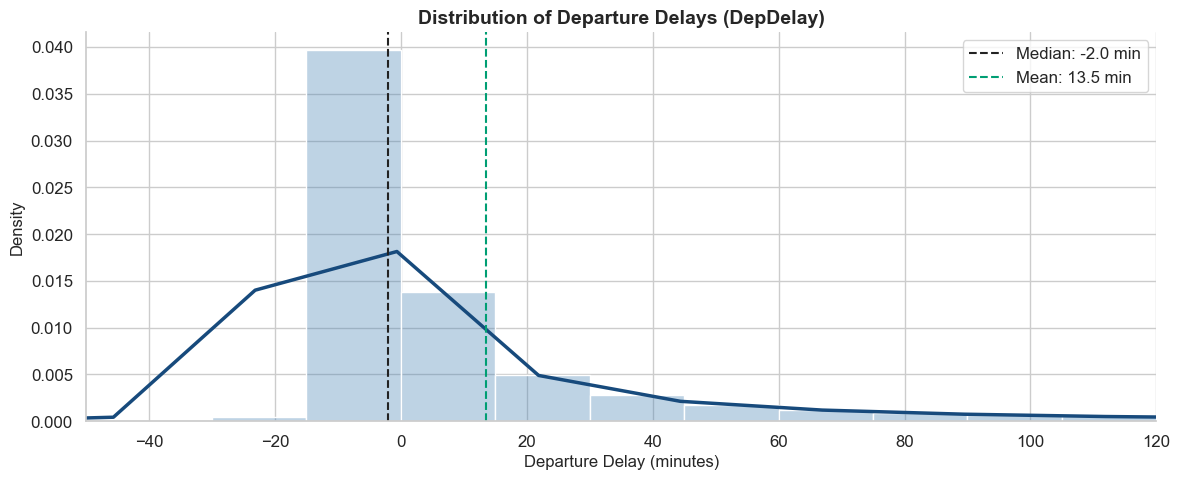

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
bin_edges = np.arange(-30, 121, 15)
sns.histplot(df_active['DepDelay'], bins=bin_edges, ax=ax, color='steelblue', stat='density', alpha=0.35)
sns.kdeplot(df_active['ArrDelay'], color='#174A7C', linewidth=2.5, ax=ax)
ax.set_title('Distribution of Departure Delays (DepDelay)', fontsize=14, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.axvline(df_active['DepDelay'].median(), color='#222222', linestyle='--', label=f"Median: {df_active['DepDelay'].median():.1f} min")
ax.axvline(df_active['DepDelay'].mean(), color='#009E73', linestyle='--', label=f"Mean: {df_active['DepDelay'].mean():.1f} min")
ax.legend()
ax.set_xlim(-50, 120)
plt.tight_layout()


**Observations:**
- The distribution is **heavily right-skewed** with a large peak near 0, indicating many flights depart on time.
- The median departure delay is much lower than the mean, confirming the long right tail of extreme delays.
- A substantial portion of flights have negative delays (departing early), which partially offsets late departures.
- The KDE shows a sharp peak at 0 and a long tail extending past 60 minutes, a classic delay distribution.


### V2: How are arrival delays distributed?

**Question:** How does the arrival delay distribution compare to departure delays?

**Visualization:** Histogram of ArrDelay with KDE overlay.


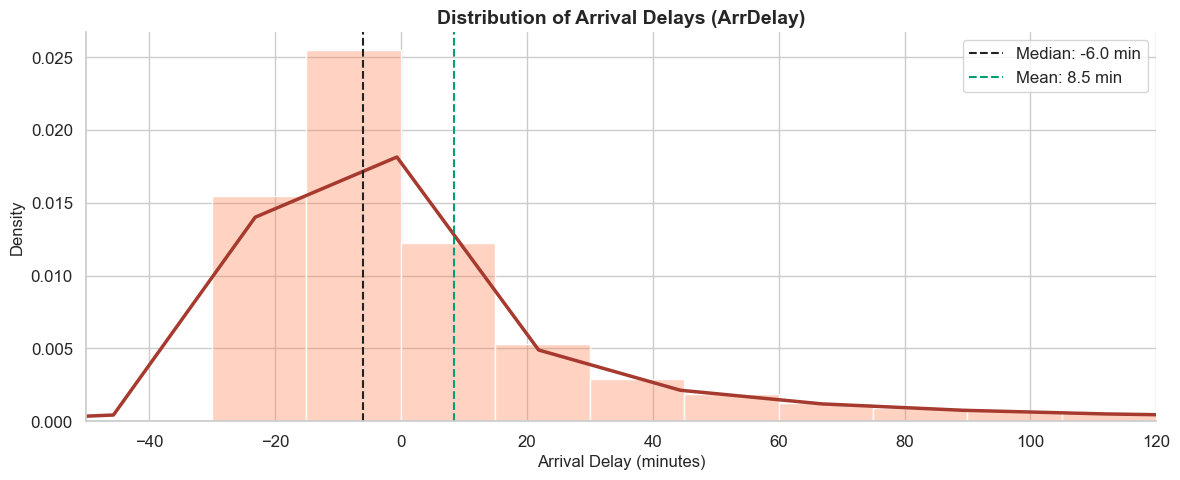

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
bin_edges = np.arange(-30, 121, 15)
sns.histplot(df_active['ArrDelay'], bins=bin_edges, ax=ax, color='coral', stat='density', alpha=0.35)
sns.kdeplot(df_active['ArrDelay'], color='#A63A2E', linewidth=2.5, ax=ax)
ax.set_title('Distribution of Arrival Delays (ArrDelay)', fontsize=14, fontweight='bold')
ax.set_xlabel('Arrival Delay (minutes)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.axvline(df_active['ArrDelay'].median(), color='#222222', linestyle='--', label=f"Median: {df_active['ArrDelay'].median():.1f} min")
ax.axvline(df_active['ArrDelay'].mean(), color='#009E73', linestyle='--', label=f"Mean: {df_active['ArrDelay'].mean():.1f} min")
ax.legend()
ax.set_xlim(-50, 120)
plt.tight_layout()


**Observations:**
- Arrival delays show a similar right-skewed pattern but with a **wider spread** than departure delays.
- The mean arrival delay is higher than the mean departure delay, suggesting delays tend to **accumulate** over the flight.
- The peak near 0 is slightly less pronounced than for departure delays, indicating fewer perfectly-on-time arrivals.
- The tail extends further, with more extreme late arrivals.


### V3: How do departure and arrival delay distributions compare?

**Question:** Which is worse, departure delays or arrival delays? How do the distributions differ?

**Visualization:** Overlaid density plots of DepDelay and ArrDelay.


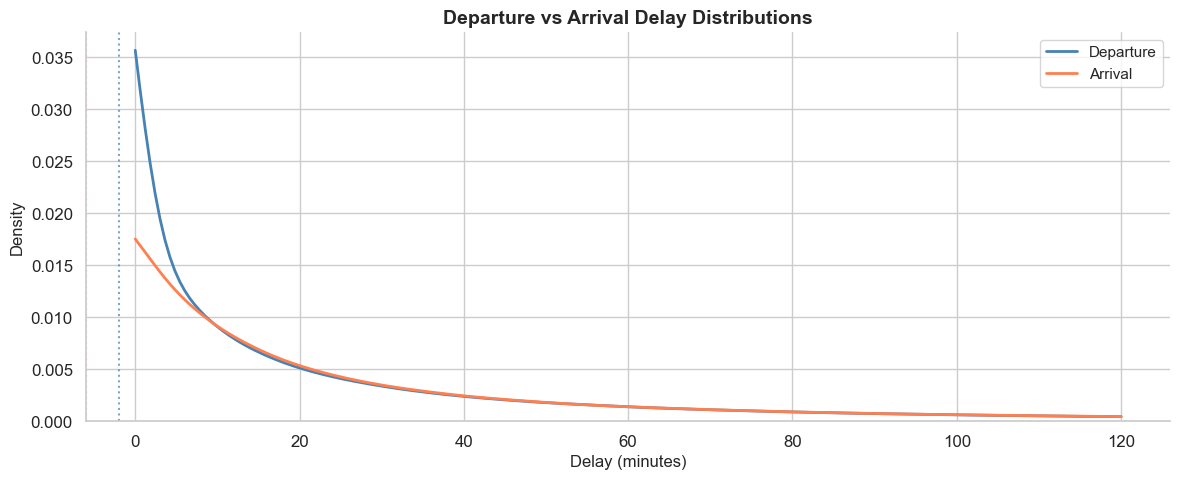

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(df_active['DepDelay'], ax=ax, color='steelblue', label='Departure', linewidth=2, clip=(0, 120))
sns.kdeplot(df_active['ArrDelay'], ax=ax, color='coral', label='Arrival', linewidth=2, clip=(0, 120))
ax.set_title('Departure vs Arrival Delay Distributions', fontsize=14, fontweight='bold')
ax.set_xlabel('Delay (minutes)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.axvline(df_active['DepDelay'].median(), color='steelblue', linestyle=':', alpha=0.7)
ax.axvline(df_active['ArrDelay'].median(), color='coral', linestyle=':', alpha=0.7)
plt.tight_layout()

**Observations:**
- **Arrival delays are consistently worse** than departure delays across the entire distribution.
- The ArrDelay density curve is shifted to the right, confirming that flights tend to arrive later relative to schedule than they departed.
- The ArrDelay distribution has a **wider spread**, more extreme late arrivals.
- The gap between the two curves widens in the 20-60 minute range, where delays accumulate most significantly.


### V4: What is the distribution of flight distance?

**Question:** How are flights distributed across short-haul, medium-haul, and long-haul distances?

**Visualization:** Histogram of Distance.


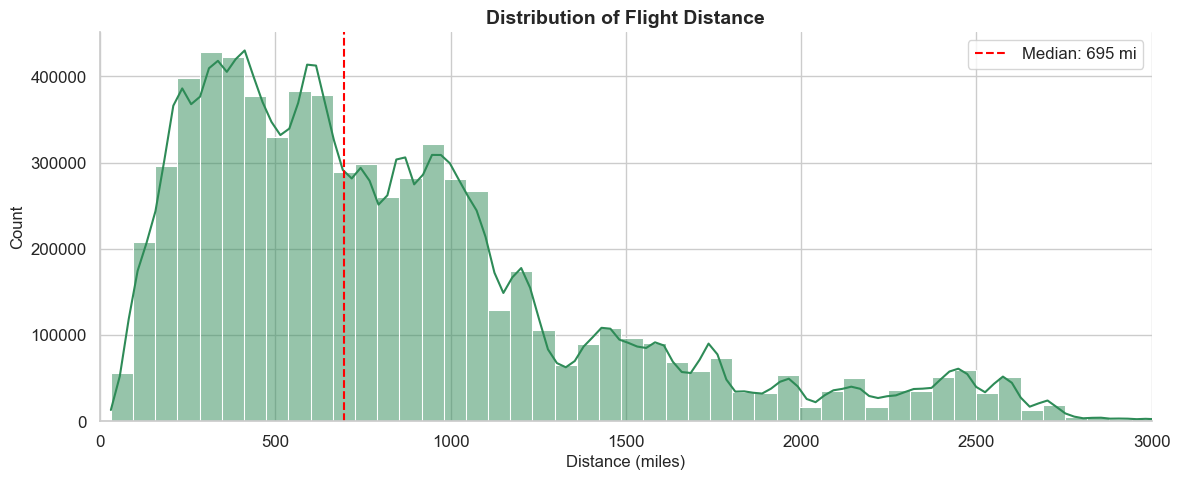

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df_active['Distance'], bins=80, kde=True, ax=ax, color='seagreen')
ax.set_title('Distribution of Flight Distance', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance (miles)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df_active['Distance'].median(), color='red', linestyle='--', label=f"Median: {df_active['Distance'].median():.0f} mi")
ax.legend()
ax.set_xlim(0, 3000)
plt.tight_layout()


**Observations:**
- Distance is **right-skewed** with a peak at shorter distances (100-500 miles), reflecting the high volume of domestic short-haul flights.
- There is a smaller shoulder around 1,500-1,800 miles, suggesting a secondary cluster of longer domestic routes, though the distribution is still primarily right-skewed rather than cleanly bimodal.
- Very few flights exceed 2,500 miles, which makes sense for a US domestic dataset.


### V5: How are delay causes distributed?

**Question:** What are the primary causes of flight delays? Which delay category contributes the most?

**Visualization:** Bar chart of mean delay by cause.


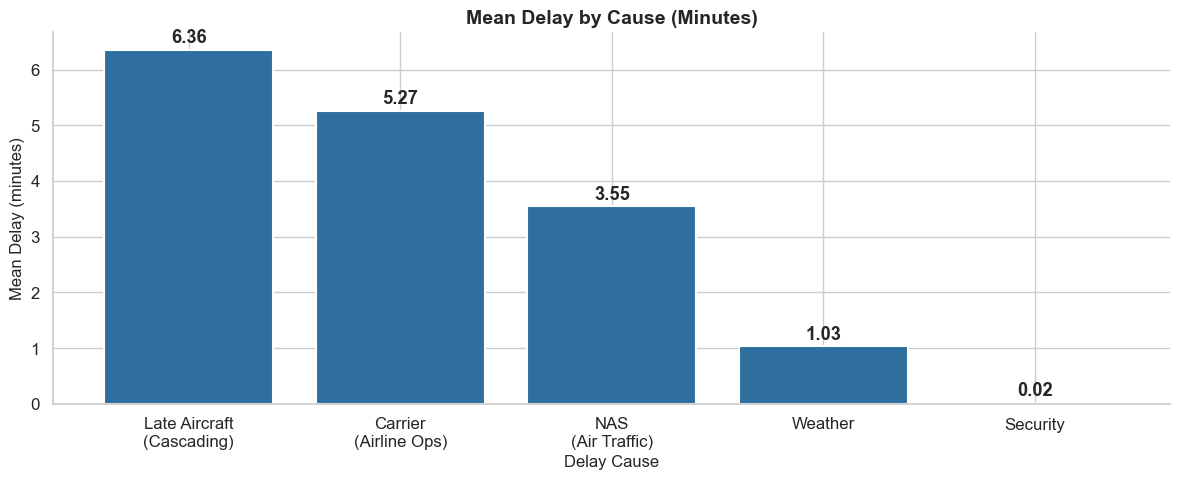

In [11]:
delay_causes = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
cause_labels = {
    'CarrierDelay': 'Carrier\n(Airline Ops)',
    'WeatherDelay': 'Weather',
    'NASDelay': 'NAS\n(Air Traffic)',
    'SecurityDelay': 'Security',
    'LateAircraftDelay': 'Late Aircraft\n(Cascading)'
}
cause_means = df_active[delay_causes].mean().sort_values(ascending=False)
cause_label_order = [cause_labels[cause] for cause in cause_means.index]

fig, ax = plt.subplots(figsize=(12, 5))
bar_color = '#2F6F9F'
bars = ax.bar(cause_label_order, cause_means.values, color=bar_color, edgecolor='white', linewidth=1.5)
ax.set_title('Mean Delay by Cause (Minutes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Delay Cause', fontsize=12)
ax.set_ylabel('Mean Delay (minutes)', fontsize=12)
for bar, val in zip(bars, cause_means.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()


**Observations:**
- **LateAircraftDelay** is the largest contributor to delays, reflecting the cascading effect of late-arriving aircraft causing subsequent departures to be delayed.
- **CarrierDelay** (airline operational issues like crew scheduling, maintenance) is the second-largest cause.
- **NASDelay** (National Air System congestion) is significant, reflecting air traffic control constraints.
- **WeatherDelay** and **SecurityDelay** are relatively minor contributors on average, though weather can be highly variable by season and region.


### V6: What proportion of flights are cancelled or diverted?

**Question:** How common are flight cancellations and diversions?

**Visualization:** Count plot of cancellation and diversion status.


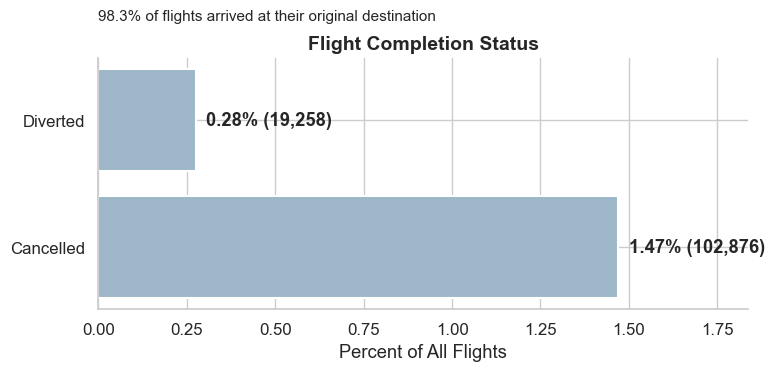

In [12]:
status_counts = pd.DataFrame({
    'Status': ['Cancelled', 'Diverted'],
    'Count': [df['Cancelled'].sum(), df['Diverted'].sum()]
})

status_counts['Percent'] = status_counts['Count'] / len(df) * 100
normal_pct = 100 - status_counts['Percent'].sum()

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    status_counts['Status'],
    status_counts['Percent'],
    color='#9DB7C8',
    edgecolor='white',
    linewidth=1.5
)

for bar, count, pct in zip(bars, status_counts['Count'], status_counts['Percent']):
    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.2f}% ({count:,.0f})',
        va='center',
        fontweight='bold'
    )

ax.set_title('Flight Completion Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Percent of All Flights')
ax.text(
    0,
    1.15,
    f'{normal_pct:.1f}% of flights arrived at their original destination',
    transform=ax.transAxes,
    fontsize=11
)

ax.set_xlim(0, status_counts['Percent'].max() * 1.25)
plt.tight_layout()


**Observations:**
The vast majority of flights, 98.3%, arrived at their original destination. Cancellations and diversions were rare but still meaningful in absolute volume given the dataset size.


## Step 3: Bivariate Exploration

Assumption: comparing pairs of variables will show whether delays are mostly explained by departure behavior, airline operations, time patterns, geography, or distance.

Questions for this section:
- How strongly do departure and arrival delays move together?
- Which airlines, days, months, and states show different delay behavior?
- Are distance and delay causes meaningful explanatory features?

Investigating relationships between pairs of variables.


### V7: How do departure delays relate to arrival delays?

**Question:** Do late departures always lead to late arrivals? What is the strength of this relationship?

**Visualization:** Hexbin plot of DepDelay vs ArrDelay (subsampled to handle 7M+ rows).


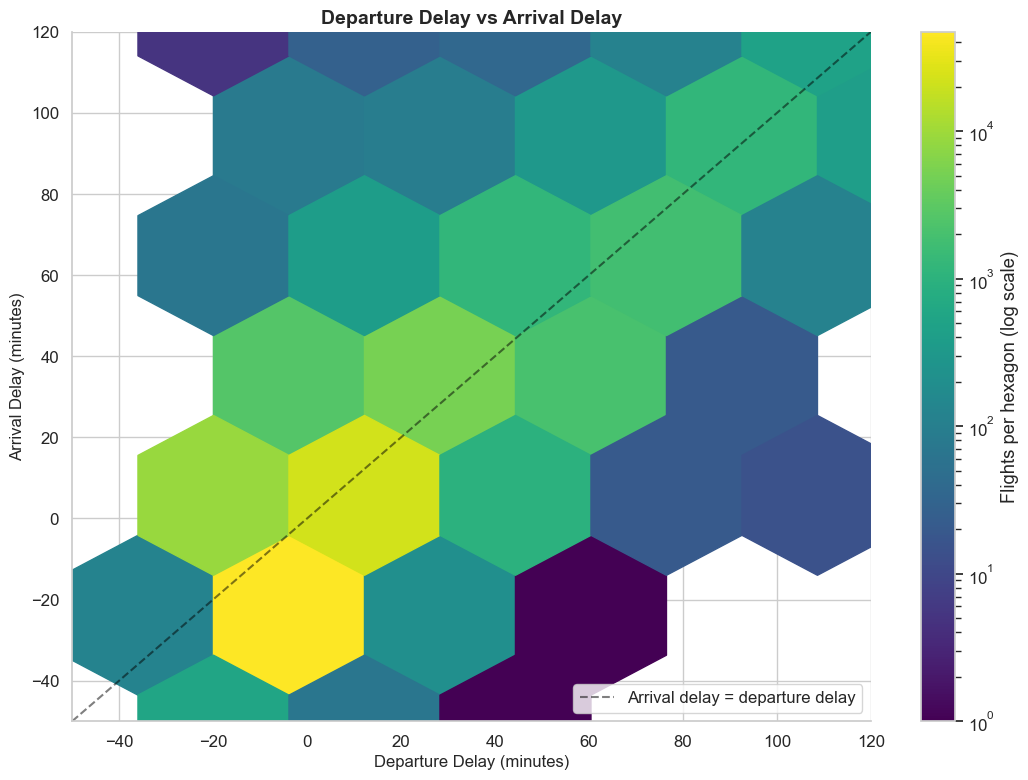

In [13]:
from matplotlib.colors import LogNorm

# Subsample for hexbin to avoid performance issues
sample = df_active.sample(n=100000, random_state=42)

fig, ax = plt.subplots(figsize=(11, 8))

hb = ax.hexbin(
    sample['DepDelay'],
    sample['ArrDelay'],
    gridsize=55,
    cmap='viridis',
    mincnt=1,
    norm=LogNorm()
)

ax.set_title('Departure Delay vs Arrival Delay', fontsize=14, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)', fontsize=12)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=12)

ax.set_xlim(-50, 120)
ax.set_ylim(-50, 120)
ax.plot([-50, 120], [-50, 120], 'k--', alpha=0.5, label='Arrival delay = departure delay')

cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('Flights per hexagon (log scale)')

ax.legend(loc='lower right')
plt.tight_layout()


**Observations:**
- There is a **strong positive relationship** between departure and arrival delays: flights that depart late usually arrive late.
- The densest region is clustered near **small delays and early/on-time arrivals**, which is clearer with the log-scaled hexbin.
- Many delayed flights fall near the **y = x** line, meaning arrival delay is often similar to departure delay.
- Points above the line indicate flights whose delays **worsened en route**, while points below the line indicate flights that **recovered some delay** before arrival.
- The spread around the line shows that departure delay is important, but not the only factor affecting arrival delay.

### V8: How do significant late departure rates vary by airline?

**Question:** Which airlines have the worst departure on-time performance?

**Visualization:** Ranked bar chart of the top 10 airlines by percent of flights departing more than 15 minutes late, with a legend mapping airline codes to full airline names.


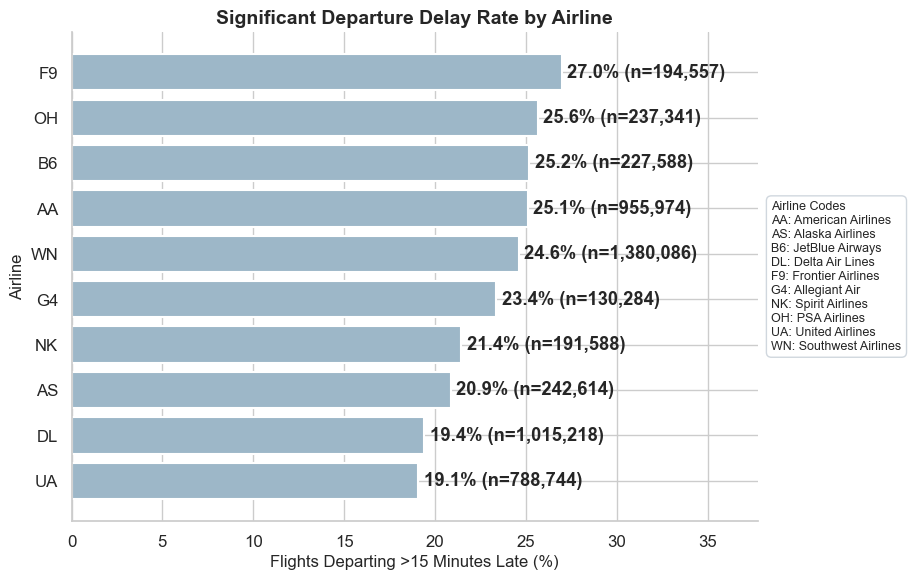

In [14]:
dep_del15_by_airline = (
    df_active.groupby('IATA_CODE_Reporting_Airline')['DepDel15']
    .agg(delay_rate='mean', flights='count')
)
dep_del15_by_airline['delay_rate'] = dep_del15_by_airline['delay_rate'] * 100
dep_del15_by_airline = (
    dep_del15_by_airline
    .sort_values('delay_rate', ascending=False)
    .head(10)
    .sort_values('delay_rate', ascending=True)
)

airline_names = {
    '9E': 'Endeavor Air',
    'AA': 'American Airlines',
    'AS': 'Alaska Airlines',
    'B6': 'JetBlue Airways',
    'DL': 'Delta Air Lines',
    'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines',
    'MQ': 'Envoy Air',
    'NK': 'Spirit Airlines',
    'OH': 'PSA Airlines',
    'OO': 'SkyWest Airlines',
    'QX': 'Horizon Air',
    'UA': 'United Airlines',
    'WN': 'Southwest Airlines',
    'YV': 'Mesa Airlines',
    'YX': 'Republic Airways'
}

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    dep_del15_by_airline.index,
    dep_del15_by_airline['delay_rate'],
    color='#9DB7C8',
    edgecolor='white',
    linewidth=1.5
)

for bar, pct, flights in zip(
    bars,
    dep_del15_by_airline['delay_rate'],
    dep_del15_by_airline['flights']
):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}% (n={flights:,.0f})',
        va='center',
        fontweight='bold'
    )

ax.set_title('Significant Departure Delay Rate by Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Flights Departing >15 Minutes Late (%)', fontsize=12)
ax.set_ylabel('Airline', fontsize=12)
ax.set_xlim(0, dep_del15_by_airline['delay_rate'].max() * 1.4)

legend_text = 'Airline Codes\n' + '\n'.join(
    f'{code}: {airline_names.get(code, code)}'
    for code in sorted(dep_del15_by_airline.index)
)
ax.text(
    1.02,
    0.5,
    legend_text,
    transform=ax.transAxes,
    va='center',
    ha='left',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D0D7DE')
)

plt.tight_layout(rect=[0, 0, 0.78, 1])


**Observations:**
- There is **meaningful variation** in the share of flights departing more than 15 minutes late across airlines.
- Ranking by `DepDel15` directly shows which airlines have the weakest departure on-time performance.
- The `n` labels show the number of active flights used to calculate each airline's delay rate.
- This chart is limited to the top 10 airlines by significant departure delay rate, so lower-rate airlines are excluded rather than grouped into 'Other'.
- This view focuses on delay frequency, not delay severity; extreme individual delays are better evaluated with a distribution plot.
- For context, Hawaiian Airlines (HA) had the lowest significant departure delay rate at 15.2%, compared with 27.0% for Frontier (F9), the highest-rate airline.


### V9: How do significant late arrival rates vary by airline?

**Question:** Which airlines have the worst arrival on-time performance? How does this compare to departure performance?

**Visualization:** Ranked bar chart of the top 10 airlines by percent of flights arriving more than 15 minutes late, with a legend mapping airline codes to full airline names.


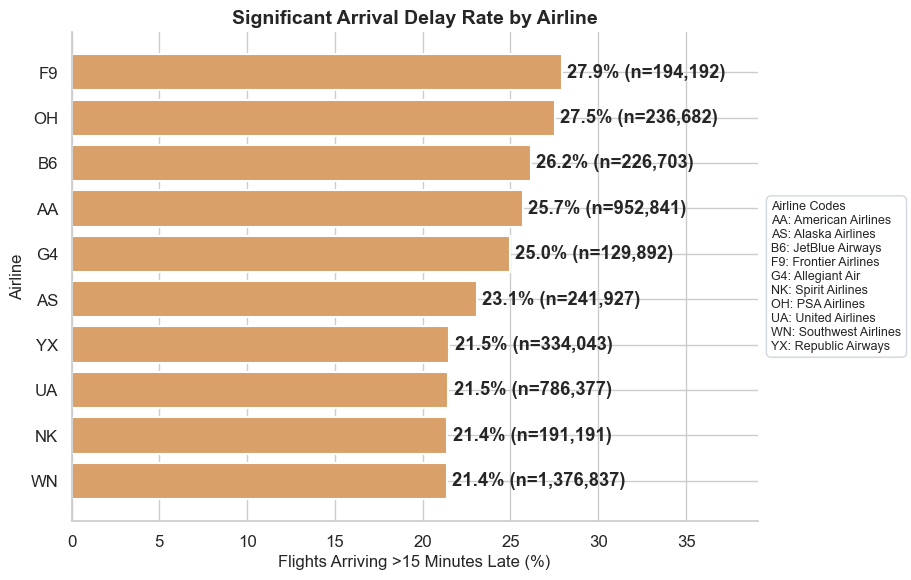

In [15]:
arr_del15_by_airline = (
    df_active.dropna(subset=['ArrDel15'])
    .groupby('IATA_CODE_Reporting_Airline')['ArrDel15']
    .agg(delay_rate='mean', flights='count')
)
arr_del15_by_airline['delay_rate'] = arr_del15_by_airline['delay_rate'] * 100
arr_del15_by_airline = (
    arr_del15_by_airline
    .sort_values('delay_rate', ascending=False)
    .head(10)
    .sort_values('delay_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    arr_del15_by_airline.index,
    arr_del15_by_airline['delay_rate'],
    color='#D9A06A',
    edgecolor='white',
    linewidth=1.5
)

for bar, pct, flights in zip(
    bars,
    arr_del15_by_airline['delay_rate'],
    arr_del15_by_airline['flights']
):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}% (n={flights:,.0f})',
        va='center',
        fontweight='bold'
    )

ax.set_title('Significant Arrival Delay Rate by Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Flights Arriving >15 Minutes Late (%)', fontsize=12)
ax.set_ylabel('Airline', fontsize=12)
ax.set_xlim(0, arr_del15_by_airline['delay_rate'].max() * 1.4)

legend_text = 'Airline Codes\n' + '\n'.join(
    f'{code}: {airline_names.get(code, code)}'
    for code in sorted(arr_del15_by_airline.index)
)
ax.text(
    1.02,
    0.5,
    legend_text,
    transform=ax.transAxes,
    va='center',
    ha='left',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D0D7DE')
)

plt.tight_layout(rect=[0, 0, 0.78, 1])


**Observations:**
- There is **meaningful variation** in the share of flights arriving more than 15 minutes late across airlines.
- Ranking by `ArrDel15` directly shows which airlines have the weakest arrival on-time performance.
- The `n` labels show the number of flights with valid arrival delay flags used to calculate each airline's rate.
- This chart is limited to the top 10 airlines by significant arrival delay rate, so lower-rate airlines are excluded rather than grouped into 'Other'.
- For context, Hawaiian Airlines (HA) had the lowest significant arrival delay rate at 17.3%, compared with 27.9% for Frontier (F9), the highest-rate airline.
- Comparing this chart with V8 shows whether airlines with weak departure punctuality also have weak arrival punctuality.


### V10: How do delays vary by day of the week?

**Question:** Are certain days of the week associated with more delays?

**Visualization:** Bar chart of the percent of flights arriving more than 15 minutes late by day of week.


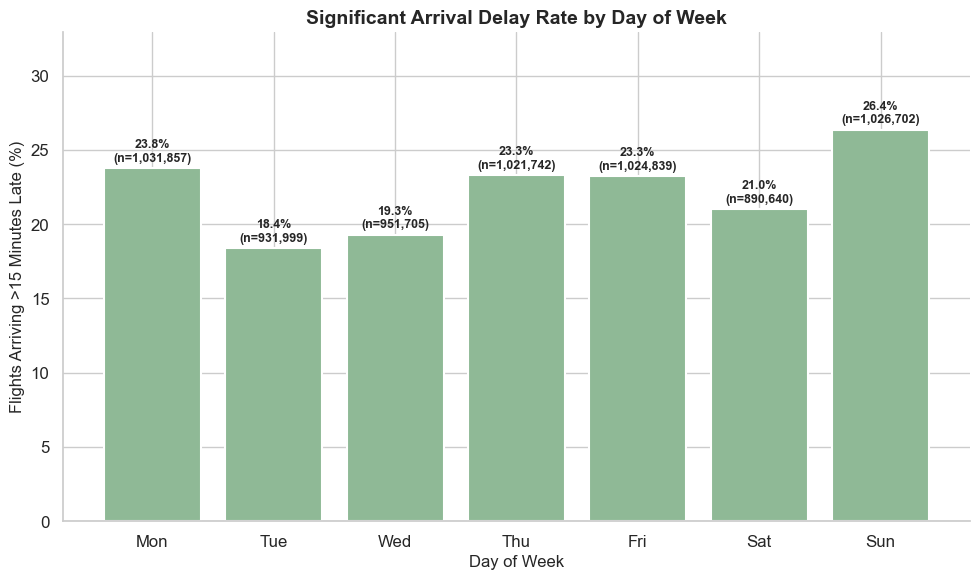

In [16]:
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_active['DayName'] = df_active['DayOfWeek'].map(day_names)

arr_del15_by_day = (
    df_active.dropna(subset=['ArrDel15'])
    .groupby('DayName')['ArrDel15']
    .agg(delay_rate='mean', flights='count')
    .reindex(day_order)
)
arr_del15_by_day['delay_rate'] = arr_del15_by_day['delay_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    arr_del15_by_day.index,
    arr_del15_by_day['delay_rate'],
    color='#8FB996',
    edgecolor='white',
    linewidth=1.5
)

for bar, pct, flights in zip(
    bars,
    arr_del15_by_day['delay_rate'],
    arr_del15_by_day['flights']
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f'{pct:.1f}%\n(n={flights:,.0f})',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9
    )

ax.set_title('Significant Arrival Delay Rate by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Flights Arriving >15 Minutes Late (%)', fontsize=12)
ax.set_ylim(0, arr_del15_by_day['delay_rate'].max() * 1.25)
plt.tight_layout()


**Observations:**
- **Sunday** has the highest significant arrival delay rate, suggesting end-of-week return travel is especially delay-prone.
- **Monday, Thursday, and Friday** also show elevated delay rates, while **Tuesday** has the lowest rate.
- The `n` labels show the number of flights with valid arrival delay flags used to calculate each day's rate.
- The weekday pattern suggests delays are not evenly distributed across the week; travel demand and schedule congestion likely matter.

### V11: How do delays vary by month?

**Question:** Are there seasonal patterns in flight delays?

**Visualization:** Line chart of the percent of flights arriving more than 15 minutes late by month.


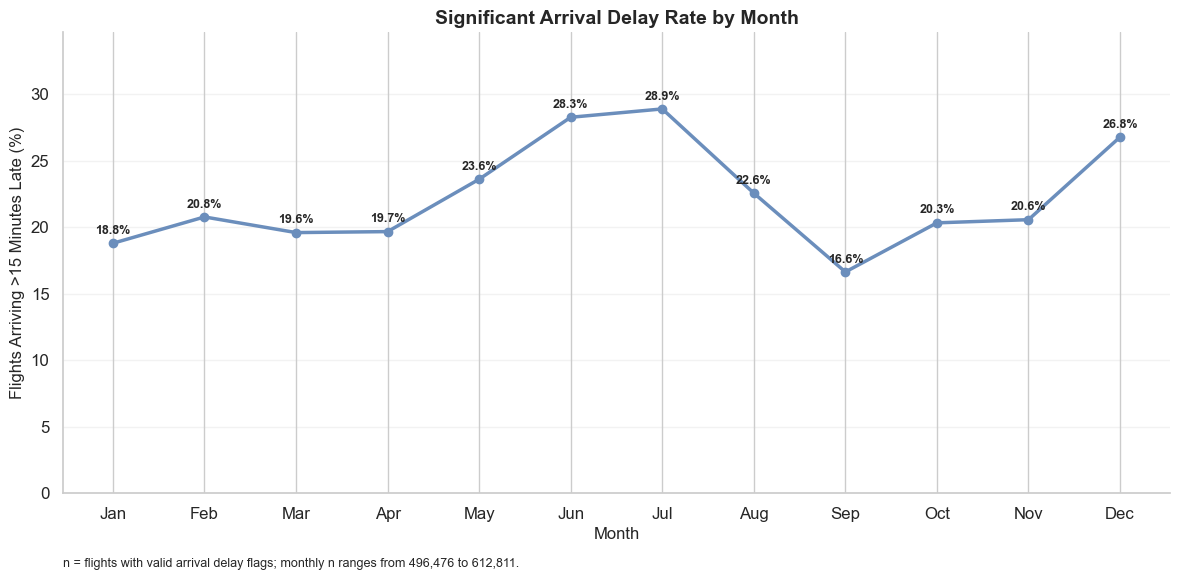

In [17]:
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

arr_del15_by_month = (
    df_active.dropna(subset=['ArrDel15'])
    .groupby('Month')['ArrDel15']
    .agg(delay_rate='mean', flights='count')
    .reindex(range(1, 13))
)
arr_del15_by_month['delay_rate'] = arr_del15_by_month['delay_rate'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    arr_del15_by_month.index,
    arr_del15_by_month['delay_rate'],
    marker='o',
    linewidth=2.5,
    color='#6B8EBC'
)

for month, pct in arr_del15_by_month['delay_rate'].items():
    ax.text(
        month,
        pct + 0.5,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9
    )

ax.set_title('Significant Arrival Delay Rate by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Flights Arriving >15 Minutes Late (%)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])
ax.set_ylim(0, arr_del15_by_month['delay_rate'].max() * 1.2)
ax.grid(axis='y', alpha=0.25)
ax.text(
    0,
    -0.16,
    'n = flights with valid arrival delay flags; monthly n ranges from '
    f'{arr_del15_by_month["flights"].min():,.0f} to '
    f'{arr_del15_by_month["flights"].max():,.0f}.',
    transform=ax.transAxes,
    fontsize=9
)
plt.tight_layout()


**Observations:**
- **June and July** have the highest significant arrival delay rates, suggesting summer travel volume and weather disruptions are major contributors.
- **December** is the strongest winter spike, but January is comparatively lower, so the winter effect is not uniform across all winter months.
- **September** has the lowest significant arrival delay rate, making it the clearest low-delay month in the year.
- The pattern suggests seasonality with a pronounced summer peak and a December holiday/weather peak.


### V12: How does flight distance relate to delay?

**Question:** Do longer flights experience more or less delay than shorter flights?

**Visualization:** Bar chart of significant arrival delay rate by flight distance range.


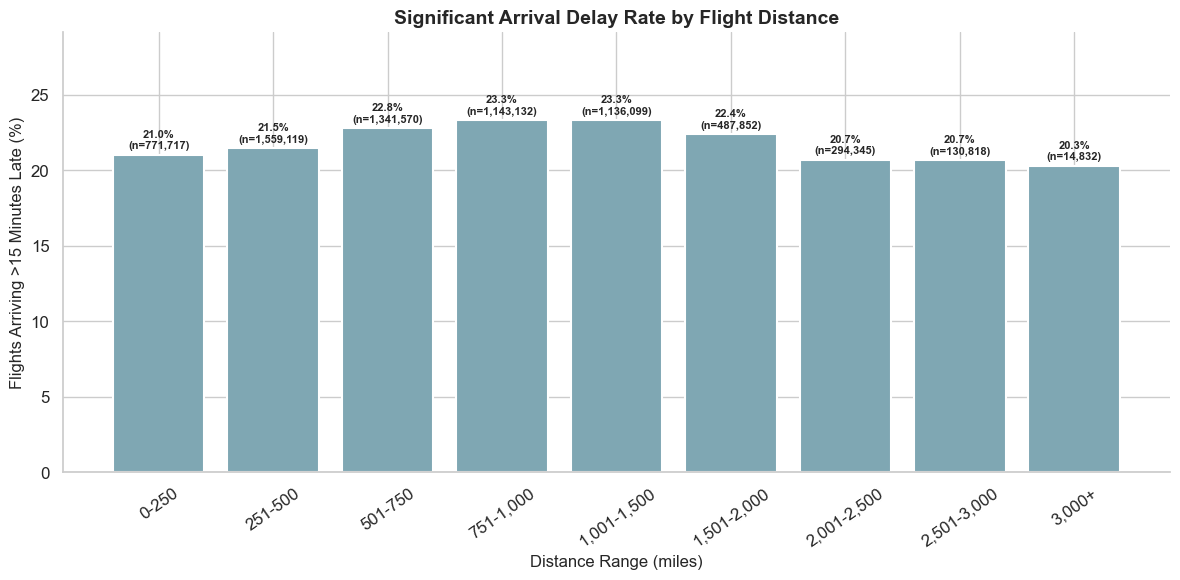

In [18]:
distance_bins = [0, 250, 500, 750, 1000, 1500, 2000, 2500, 3000, np.inf]
distance_labels = [
    '0-250', '251-500', '501-750', '751-1,000',
    '1,001-1,500', '1,501-2,000', '2,001-2,500',
    '2,501-3,000', '3,000+'
]
df_active['DistanceBin'] = pd.cut(
    df_active['Distance'],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

arr_del15_by_distance = (
    df_active.dropna(subset=['ArrDel15', 'DistanceBin'])
    .groupby('DistanceBin', observed=False)['ArrDel15']
    .agg(delay_rate='mean', flights='count')
    .reindex(distance_labels)
)
arr_del15_by_distance['delay_rate'] = arr_del15_by_distance['delay_rate'] * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    arr_del15_by_distance.index,
    arr_del15_by_distance['delay_rate'],
    color='#7FA7B3',
    edgecolor='white',
    linewidth=1.5
)

for bar, pct, flights in zip(
    bars,
    arr_del15_by_distance['delay_rate'],
    arr_del15_by_distance['flights']
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f'{pct:.1f}%\n(n={flights:,.0f})',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=8
    )

ax.set_title('Significant Arrival Delay Rate by Flight Distance', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance Range (miles)', fontsize=12)
ax.set_ylabel('Flights Arriving >15 Minutes Late (%)', fontsize=12)
ax.set_ylim(0, arr_del15_by_distance['delay_rate'].max() * 1.25)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()


**Observations:**
- Significant arrival delay rates are fairly flat across distance ranges, ranging only from about **20% to 23%**.
- The highest rates appear in the **751-1,500 mile** range, but the difference from shorter flights is modest.
- Very long flights (`3,000+` miles) have the lowest observed rate, but this bin has far fewer flights, so it should be interpreted cautiously.
- Overall, distance alone appears to be a weak predictor of significant arrival delays; route, airport, weather, and schedule conditions likely matter more.

### V13: How do delay causes vary by airline?

**Question:** Do different airlines experience different types of delays?

**Visualization:** Small-multiple horizontal bar charts of mean delay minutes by cause for the top 5 airlines by total mean delay plus Other, excluding SecurityDelay.


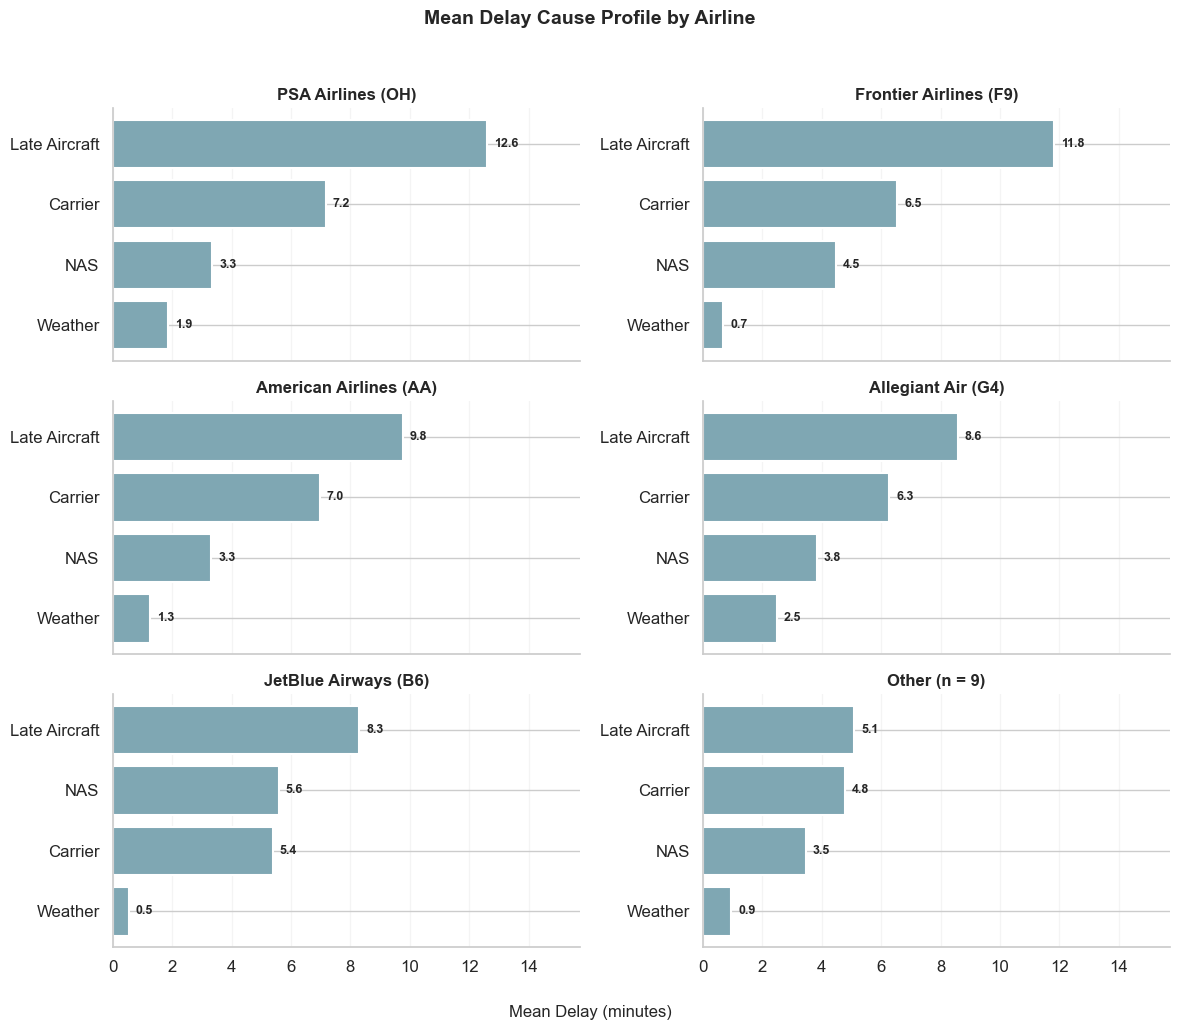

In [19]:
delay_causes_no_security = [cause for cause in delay_causes if cause != 'SecurityDelay']
mean_delay_by_airline = (
    df_active
    .assign(TotalCauseDelay=df_active[delay_causes_no_security].sum(axis=1))
    .groupby('IATA_CODE_Reporting_Airline')['TotalCauseDelay']
    .mean()
    .sort_values(ascending=False)
)
top_5_delay_airlines = mean_delay_by_airline.head(5).index.tolist()
other_airline_count = mean_delay_by_airline.index.difference(top_5_delay_airlines).size
cause_df = df_active.assign(
    AirlineCauseGroup=df_active['IATA_CODE_Reporting_Airline'].where(
        df_active['IATA_CODE_Reporting_Airline'].isin(top_5_delay_airlines),
        'Other'
    )
)
cause_by_airline = cause_df.groupby('AirlineCauseGroup')[delay_causes_no_security].mean()
airline_order = top_5_delay_airlines + ['Other']
cause_by_airline = cause_by_airline.loc[airline_order]
airline_names = {
    '9E': 'Endeavor Air',
    'AA': 'American Airlines',
    'AS': 'Alaska Airlines',
    'B6': 'JetBlue Airways',
    'DL': 'Delta Air Lines',
    'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines',
    'MQ': 'Envoy Air',
    'NK': 'Spirit Airlines',
    'OH': 'PSA Airlines',
    'OO': 'SkyWest Airlines',
    'QX': 'Horizon Air',
    'UA': 'United Airlines',
    'WN': 'Southwest Airlines',
    'YV': 'Mesa Airlines',
    'YX': 'Republic Airways'
}
cause_labels = {
    'CarrierDelay': 'Carrier',
    'WeatherDelay': 'Weather',
    'NASDelay': 'NAS',
    'LateAircraftDelay': 'Late Aircraft'
}
cause_profile = cause_by_airline.rename(columns=cause_labels)

x_max = cause_profile.max().max() * 1.25
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

for ax, airline in zip(axes, airline_order):
    profile = cause_profile.loc[airline].sort_values()
    bars = ax.barh(
        profile.index,
        profile.values,
        color='#7FA7B3',
        edgecolor='white',
        linewidth=1.5
    )
    for bar, value in zip(bars, profile.values):
        ax.text(
            bar.get_width() + x_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}',
            va='center',
            fontsize=9,
            fontweight='bold'
        )
    title = f'Other (n = {other_airline_count})' if airline == 'Other' else f'{airline_names.get(airline, airline)} ({airline})'
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, x_max)
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('Mean Delay Cause Profile by Airline', fontsize=14, fontweight='bold', y=1.02)
fig.supxlabel('Mean Delay (minutes)', fontsize=12)
plt.tight_layout()


**Observations:**
- The airline panels show the top 5 airlines by total mean delay-cause minutes, ordered from highest to lowest, plus an `Other` group.
- **Late aircraft delay** is the strongest cause for several airline groups, reflecting the cascading nature of delayed inbound aircraft.
- **Carrier delay** and **NAS delay** vary by airline, suggesting differences in operations, hub exposure, and route networks.
- The `Other` panel summarizes all airlines outside the top 5 by total mean delay, so it represents a mixed operating profile rather than one carrier.
- **SecurityDelay** is excluded from this chart because it is minimal across airlines and compressed the more meaningful differences.


## Step 4: Multivariate Exploration

Assumption: meaningful delay patterns depend on interacting factors, such as day plus time of day, airline plus distance, or departure delay plus en-route recovery.

Questions for this section:
- Which relationships remain visible when a third variable is added?
- Do some contexts compound delays while others recover them?
- Which multivariate findings are strong enough to polish for the explanatory notebook?

Investigating relationships among three or more variables.


### V14: How do delays vary by time of day AND day of week?

**Question:** Are there specific day/time combinations that experience more delays?

**Visualization:** Annotated heatmap of the significant arrival delay rate by DayOfWeek and TimeOfDay.


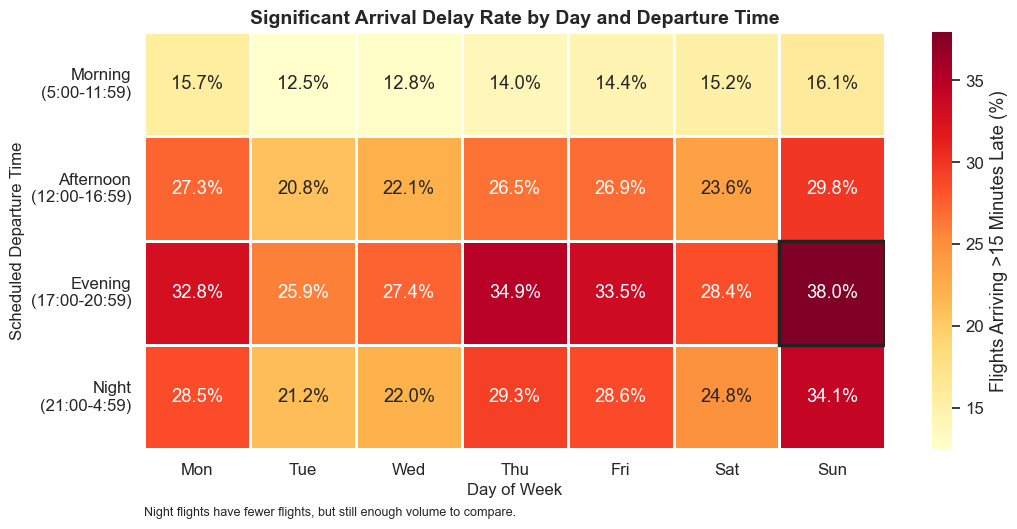

In [29]:
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_labels = {
    'Morning': 'Morning\n(5:00-11:59)',
    'Afternoon': 'Afternoon\n(12:00-16:59)',
    'Evening': 'Evening\n(17:00-20:59)',
    'Night': 'Night\n(21:00-4:59)'
}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

arr_delay_by_day_time = (
    df_active.dropna(subset=['ArrDel15', 'DayName', 'TimeOfDay'])
    .groupby(['TimeOfDay', 'DayName'])['ArrDel15']
    .agg(delay_rate='mean', flights='count')
)
arr_delay_by_day_time['delay_rate'] = arr_delay_by_day_time['delay_rate'] * 100

delay_heatmap = (
    arr_delay_by_day_time['delay_rate']
    .unstack('DayName')
    .reindex(index=time_order, columns=day_order)
)
flight_counts = (
    arr_delay_by_day_time['flights']
    .unstack('DayName')
    .reindex(index=time_order, columns=day_order)
)
annot = delay_heatmap.round(1).astype(str) + '%'

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(
    delay_heatmap,
    annot=annot,
    fmt='',
    cmap='YlOrRd',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Flights Arriving >15 Minutes Late (%)'},
    ax=ax
)

max_time, max_day = delay_heatmap.stack().idxmax()
max_row = time_order.index(max_time)
max_col = day_order.index(max_day)
ax.add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='#222222', lw=2.5))

ax.set_title('Significant Arrival Delay Rate by Day and Departure Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Scheduled Departure Time', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.set_yticklabels([time_labels[label] for label in time_order], rotation=0)
ax.text(
    0,
    -0.16,
    'Night flights have fewer flights, but still enough volume to compare.',
    transform=ax.transAxes,
    fontsize=9
)
plt.tight_layout()


**Observations:**
- **Sunday evening** has the highest significant arrival delay rate at **38.0%**, followed by **Thursday evening** (34.9%) and **Sunday night** (34.1%).
- Delay risk rises strongly through the day: morning cells stay around **12.5%-16.1%**, while evening cells range from **25.9%-38.0%**.
- **Tuesday** is the lowest-delay weekday across every time-of-day band.
- **Friday evening** remains elevated at **33.5%**, but it is not the peak once the day/time interaction is aggregated cleanly.
- **Night flights are also delay-prone**, especially Sunday night at **34.1%**, though night has fewer flights than the daytime periods.


### V15: How do departure and arrival delays vary by origin state?

**Question:** Do some states consistently delay departures but recover en route? Do some only delay arrivals?

**Visualization:** Horizontal dumbbell plot of mean DepDelay and ArrDelay by OriginState (top 10 states by largest absolute arrival-departure gap).


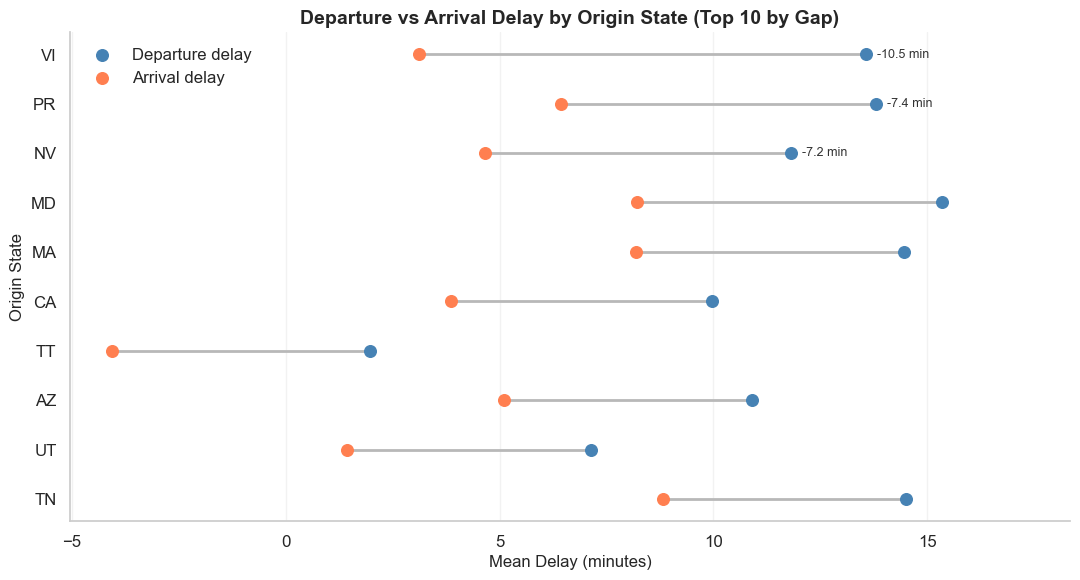

In [31]:
state_delays = df_active.groupby('OriginState').agg({
    'DepDelay': 'mean',
    'ArrDelay': 'mean'
})
state_delays['DelayDelta'] = state_delays['ArrDelay'] - state_delays['DepDelay']

top_states = state_delays['DelayDelta'].abs().sort_values(ascending=False).head(10).index
state_delays = state_delays.loc[top_states].sort_values(
    'DelayDelta', key=lambda values: values.abs(), ascending=False
)

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(state_delays))

ax.hlines(
    y=y,
    xmin=state_delays['DepDelay'],
    xmax=state_delays['ArrDelay'],
    color='#B8B8B8',
    linewidth=2,
    zorder=1
)
ax.scatter(state_delays['DepDelay'], y, color='steelblue', s=70, label='Departure delay', zorder=2)
ax.scatter(state_delays['ArrDelay'], y, color='coral', s=70, label='Arrival delay', zorder=3)

label_states = state_delays['DelayDelta'].abs().nlargest(3).index
for state in label_states:
    row = state_delays.loc[state]
    y_pos = state_delays.index.get_loc(state)
    x_pos = max(row['DepDelay'], row['ArrDelay'])
    ax.annotate(
        f"{row['DelayDelta']:+.1f} min",
        xy=(x_pos, y_pos),
        xytext=(8, 0),
        textcoords='offset points',
        va='center',
        fontsize=9,
        color='#333333'
    )

x_min = state_delays[['DepDelay', 'ArrDelay']].min().min()
x_max = state_delays[['DepDelay', 'ArrDelay']].max().max()
ax.set_xlim(min(0, x_min - 1), x_max + 3)
ax.set_yticks(y)
ax.set_yticklabels(state_delays.index)
ax.invert_yaxis()
ax.set_title('Departure vs Arrival Delay by Origin State (Top 10 by Gap)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Delay (minutes)', fontsize=12)
ax.set_ylabel('Origin State', fontsize=12)
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()


**Observations:**
- In the 2025 data, the largest origin-state gaps are recoveries: mean arrival delay is lower than mean departure delay for the highlighted states.
- The longest connectors are intentionally placed at the top, with the labeled values showing the largest average changes.
- Sorting by absolute `DelayDelta` makes the biggest departure-to-arrival differences easiest to scan.
- The top 10 selection focuses the view on the states and territories where the gap is most visible.


### V16: How do departure and arrival delay patterns vary by airline and distance?

**Question:** Do airlines show different departure-to-arrival delay patterns across short, medium, and long routes?

**Visualization:** Faceted aggregated scatter: one point per airline per distance range, with x=mean DepDelay, y=mean ArrDelay, color=airline, and point size=flight count.


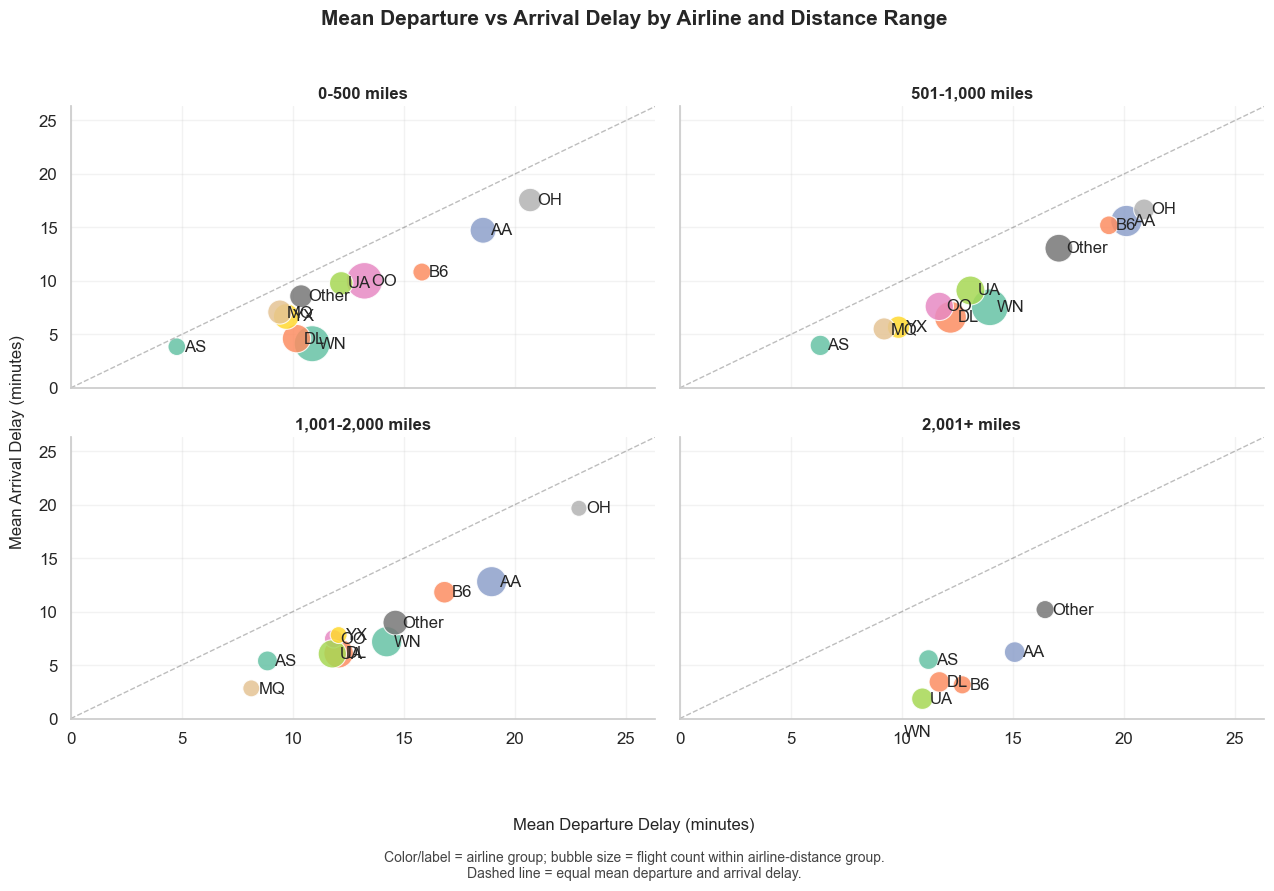

In [36]:
v16_distance_bins = [0, 500, 1000, 2000, np.inf]
v16_distance_labels = ['0-500', '501-1,000', '1,001-2,000', '2,001+']
df_active['V16DistanceRange'] = pd.cut(
    df_active['Distance'],
    bins=v16_distance_bins,
    labels=v16_distance_labels,
    include_lowest=True
)

airline_order = top_airlines + ['Other']
palette = sns.color_palette('Set2', len(top_airlines))
airline_colors = dict(zip(top_airlines, palette))
airline_colors['Other'] = '#777777'

v16_summary = (
    df_active.dropna(subset=['DepDelay', 'ArrDelay', 'Distance', 'V16DistanceRange', 'AirlineGroup'])
    .groupby(['V16DistanceRange', 'AirlineGroup'], observed=True)
    .agg(
        mean_dep_delay=('DepDelay', 'mean'),
        mean_arr_delay=('ArrDelay', 'mean'),
        flights=('DepDelay', 'size')
    )
    .reset_index()
)

x_max = max(10, v16_summary[['mean_dep_delay', 'mean_arr_delay']].max().max() * 1.15)
v16_summary['point_size'] = 130 + (v16_summary['flights'] / v16_summary['flights'].max()) * 570

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.flatten()

for ax, distance_range in zip(axes, v16_distance_labels):
    panel = (
        v16_summary[v16_summary['V16DistanceRange'] == distance_range]
        .set_index('AirlineGroup')
        .reindex(airline_order)
        .dropna(subset=['mean_dep_delay', 'mean_arr_delay'])
        .reset_index()
    )
    ax.scatter(
        panel['mean_dep_delay'],
        panel['mean_arr_delay'],
        s=panel['point_size'],
        c=panel['AirlineGroup'].map(airline_colors),
        alpha=0.85,
        edgecolor='white',
        linewidth=0.8
    )
    for _, row in panel.iterrows():
        ax.text(
            row['mean_dep_delay'] + x_max * 0.012,
            row['mean_arr_delay'],
            row['AirlineGroup'],
            fontsize=12,
            va='center'
        )

    ax.plot([0, x_max], [0, x_max], color='#444444', linestyle='--', alpha=0.35, linewidth=1)
    ax.set_title(f'{distance_range} miles', fontsize=12, fontweight='bold')
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, x_max)
    ax.grid(alpha=0.25)

fig.suptitle('Mean Departure vs Arrival Delay by Airline and Distance Range', fontsize=15, fontweight='bold')
fig.supxlabel('Mean Departure Delay (minutes)', fontsize=12, y=0.065)
fig.supylabel('Mean Arrival Delay (minutes)', fontsize=12)
fig.text(
    0.5,
    0.015,
    'Color/label = airline group; bubble size = flight count within airline-distance group.\n'
    'Dashed line = equal mean departure and arrival delay.',
    ha='center',
    fontsize=10,
    color='#444444'
)
plt.tight_layout(rect=[0, 0.10, 1, 0.96])


**Observations:**
- All airline-distance groups fall below the y=x line, indicating that mean arrival delay is lower than mean departure delay in this aggregated view.
- Faceting by distance separates the distance effect from the airline color encoding, instead of asking bubble size to carry that comparison.
- Sparse long-distance airline/range combinations are visually distinguishable from high-volume patterns.


### V17: Do delays compound or dissipate over the course of a flight?

**Question:** Do late flights get worse or better over the course of the flight?

**Visualization:** Scatter plot of DelayDelta (ArrDelay - DepDelay) vs DepDelay, with box plot inset.


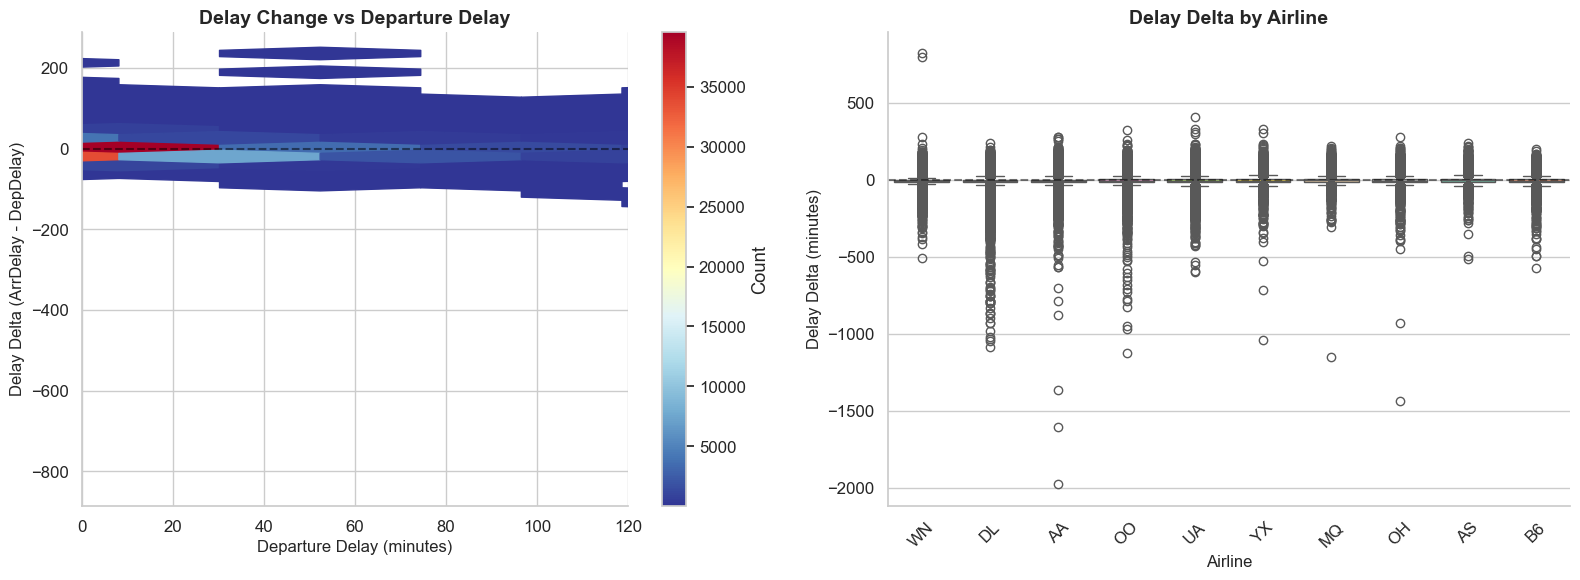

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scatter of DelayDelta vs DepDelay
hb = ax1.hexbin(sample['DepDelay'], sample['DelayDelta'], gridsize=40, cmap='RdYlBu_r', mincnt=1)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_title('Delay Change vs Departure Delay', fontsize=14, fontweight='bold')
ax1.set_xlabel('Departure Delay (minutes)', fontsize=12)
ax1.set_ylabel('Delay Delta (ArrDelay - DepDelay)', fontsize=12)
ax1.set_xlim(0, 120)
plt.colorbar(hb, ax=ax1, label='Count')

# Right: Box plot of DelayDelta by airline
sns.boxplot(data=df_active, x='AirlineGroup', y='DelayDelta', ax=ax2, palette='Set2', order=top_airlines)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Delay Delta by Airline', fontsize=14, fontweight='bold')
ax2.set_xlabel('Airline', fontsize=12)
ax2.set_ylabel('Delay Delta (minutes)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()


**Observations:**
- **Most flights have a positive delay delta** (ArrDelay > DepDelay), meaning delays tend to **compound** over the course of a flight.
- The scatter plot shows that flights with larger departure delays tend to have **larger positive deltas** — late flights get worse.
- However, there is a **cluster of points below the zero line**, indicating some flights recover delay en route (possibly due to catching up time or favorable tailwinds).
- The airline box plot shows that some airlines have **median delay deltas closer to zero**, suggesting better en-route recovery capabilities.


### V18: Plot matrix of key numeric variables

**Question:** What is the correlation structure across all key numeric variables?

**Visualization:** Pair plot (scatter matrix) of DepDelay, ArrDelay, Distance, ActualElapsedTime.


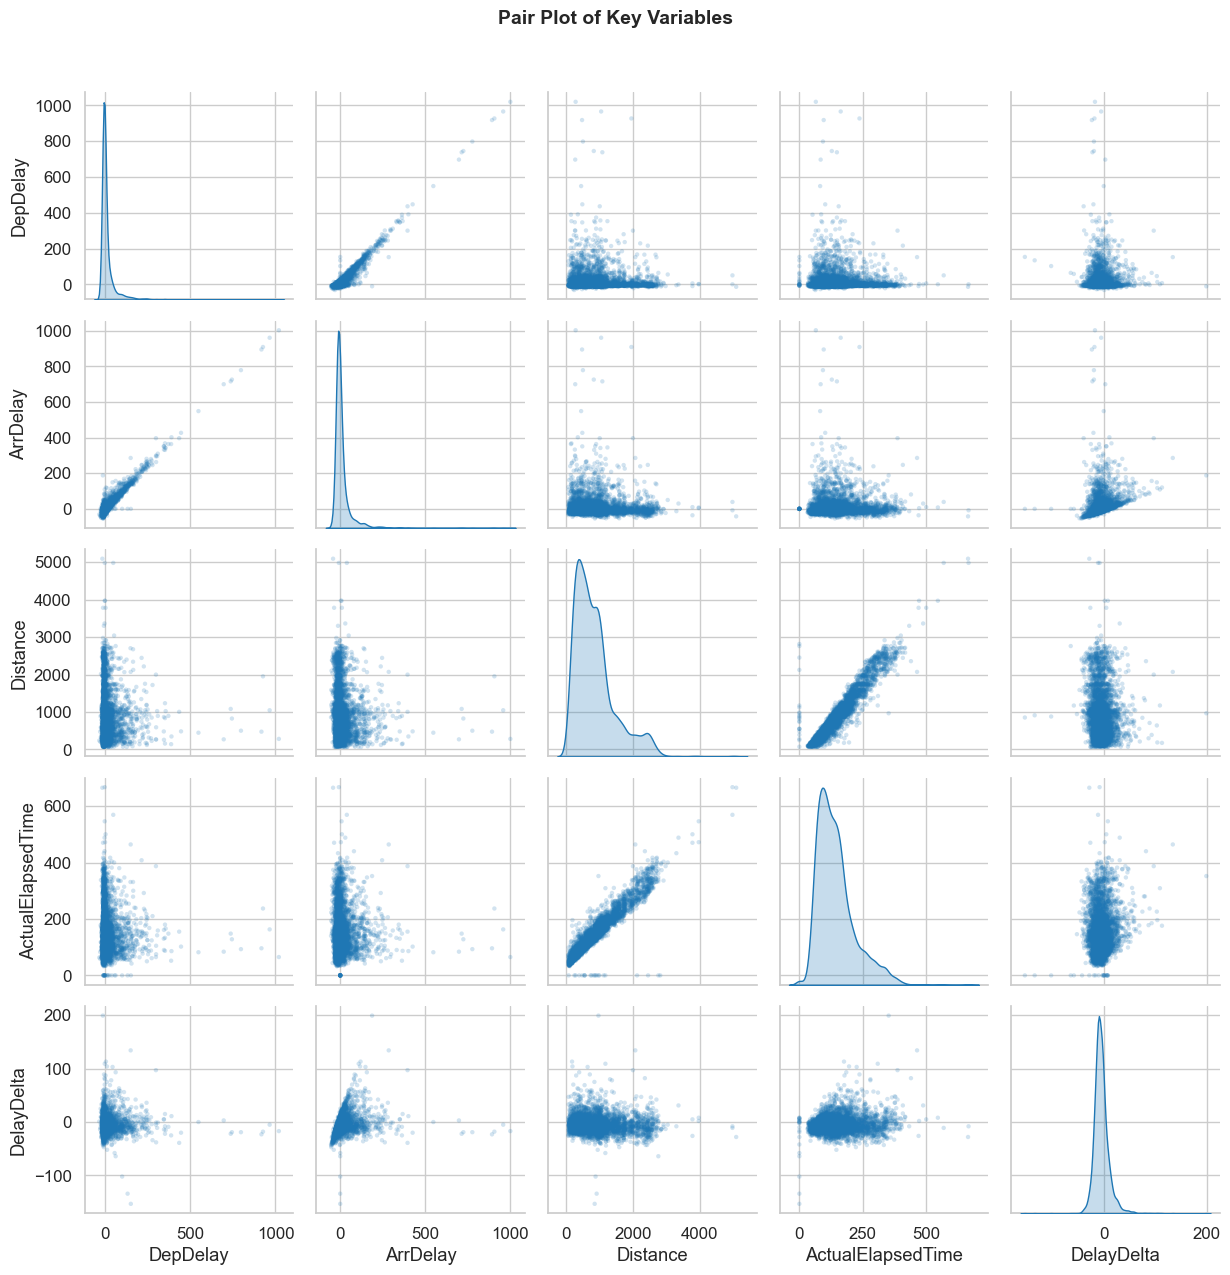

In [24]:
plot_cols = ['DepDelay', 'ArrDelay', 'Distance', 'ActualElapsedTime', 'DelayDelta']
plot_sample = df_active[plot_cols].sample(n=5000, random_state=42)

g = sns.pairplot(plot_sample, diag_kind='kde', plot_kws={'alpha': 0.2, 's': 10, 'edgecolor': 'none'})
g.fig.suptitle('Pair Plot of Key Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()


**Observations:**
- **DepDelay and ArrDelay** show a strong positive correlation (upper-right scatter), confirming the relationship seen in V7.
- **Distance and ActualElapsedTime** are strongly correlated (as expected — longer flights take more time).
- **DelayDelta** shows a weak positive correlation with DepDelay — late departures tend to get worse.
- The diagonal KDEs confirm the right-skewed distributions of delay variables and the more symmetric distribution of Distance.


## Conclusions

### Summary of Main Findings

1. **Delays compound over the flight:** The median delay delta (ArrDelay - DepDelay) is positive, meaning flights tend to arrive later relative to schedule than they departed. Late departures are particularly prone to worsening en route.

2. **Airline operations are the dominant delay driver:** LateAircraftDelay and CarrierDelay are the largest contributors to overall delays. This suggests that airline operational efficiency (crew scheduling, aircraft turnaround, maintenance) is more impactful than weather or air traffic control.

3. **Sunday and late-day flights are most delay-prone:** Significant arrival delay rates peak on Sunday, especially in the evening, while Thursday and Friday evenings are also elevated and Tuesday is consistently lower.

4. **Seasonal bimodality:** Delays are elevated in both winter (weather) and summer (thunderstorms + volume), with spring and fall showing the best on-time performance.

5. **Hub states drive congestion:** States with major hub airports show consistently higher delays, but the gap between departure and arrival delays varies — some hubs recover en route while others worsen.

6. **Distance is a weak predictor:** While longer flights tend to have slightly higher delays, the relationship is noisy. Local factors (airport congestion, weather) matter more than distance.

### Reflections

- **NaN handling was critical:** Treating NaN delays as 0 (on-time) rather than missing data was essential for correct analysis.
- **Subsampling was necessary:** With 7M+ flights, hexbin plots and pair plots required subsampling to maintain performance.
- **The departure/arrival comparison framing** revealed insights that a single-delay analysis would miss — particularly how delays accumulate and which airlines recover best en route.

### Dead Ends and Unexpected Findings

- **SecurityDelay was negligible:** Security delay contribution is minimal in modern data.
- **Cancellation analysis was limited:** Cancelled flights have NaN delays, so they were excluded from delay analysis. A separate analysis of cancellation predictors would be valuable for Part II.
- **Route-level analysis was not pursued:** Origin-Dest pairs would reveal route-specific patterns but would require significant additional computation.


## Export

To export this notebook as HTML, run:

```bash
jupyter nbconvert Part_I_exploration.ipynb --to html
```
